In [5]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated

In [6]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    discriminant: float
    roots: list[float]

In [7]:
def get_equation(state: QuadState) -> QuadState:
    print(f"{state['a']}x^2 {state['b']} {state['c']}")
    return state


def calc_discriminanat(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    c = state['c']
    state['discriminant'] = (b**2) - (4*a*c)

    return state

def check_condition(state: QuadState) -> Literal['real_roots', 'repetad_roots', 'no_real_roots']:
    if state['discriminant'] > 0:
        return "real_roots"
    
    if state['discriminant'] == 0:
        return "repetad_roots"
    
    if state['discriminant'] < 0:
        return "no_real_roots"


def real_roots(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    c = state['c']

    roots = -b + (b**2 - (4*a*c)) / 2*a

    state['roots'] = roots
    return state

def repetad_roots(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    c = state['c']

    roots = -b + (b**2 - (4*a*c)) / 2*a
    
    state['roots'] = roots
    return state

def no_real_roots(state: QuadState) -> QuadState:
    pass



In [8]:
graph = StateGraph(QuadState)

graph.add_node('get_equation', get_equation)
graph.add_node('calc_discriminanat', calc_discriminanat)
# graph.add_node('check_condition', check_condition)
graph.add_node('real_roots', real_roots)
graph.add_node('repetad_roots', repetad_roots)
graph.add_node('no_real_roots', no_real_roots)


graph.add_edge(START, 'get_equation')
graph.add_edge('get_equation', 'calc_discriminanat')
graph.add_conditional_edges('calc_discriminanat', check_condition)
graph.add_edge('real_roots', END)
graph.add_edge('repetad_roots', END)
graph.add_edge('no_real_roots', END)

workflow = graph.compile()

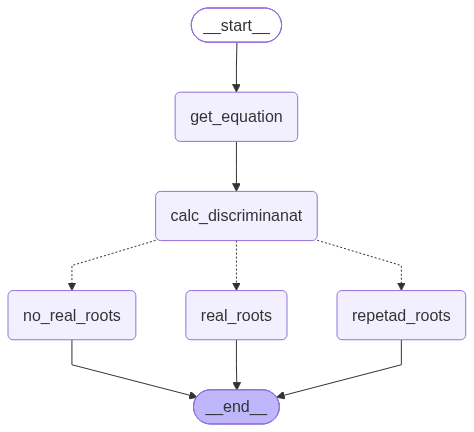

In [9]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())